In [15]:
import torch 
from torch import nn,optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu' )
tf = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

In [16]:
train_data= DataLoader(
    datasets.ImageFolder('data/Training',tf),
    batch_size =32, shuffle=True,num_workers = 0
)
test_data= DataLoader(
    datasets.ImageFolder('data/Testing',tf),
    batch_size =32, shuffle=True,num_workers = 0
)

In [17]:
model = nn.Sequential(
    nn.Conv2d(3,32,3,1,1), nn.ReLU(),nn.MaxPool2d(2),
    nn.Conv2d(32,64,3,1,1), nn.ReLU(),nn.MaxPool2d(2),
    nn.Conv2d(64,128,3,1,1), nn.ReLU(),nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(128 * 16 * 16,256),nn.ReLU(),nn.Dropout(0.5),
    nn.Linear(256,3) # 3 classes
).to(device)

In [18]:
opt = optim.AdamW(model.parameters(),1e-3)
loss_fn = nn.CrossEntropyLoss()

In [19]:
model.train()
for epoch in range(15):
    running_loss = 0
    for x,y in train_data:
        opt.zero_grad()
        loss = loss_fn(model(x.to(device)), y.to(device))
        loss.backward()
        running_loss += loss
        opt.step()
    print(f"epoch {epoch+1} loss was {running_loss}")

epoch 1 loss was 60.4698371887207
epoch 2 loss was 43.82029724121094
epoch 3 loss was 36.77783966064453
epoch 4 loss was 31.87931251525879
epoch 5 loss was 29.621793746948242
epoch 6 loss was 26.045570373535156
epoch 7 loss was 22.95323371887207
epoch 8 loss was 22.052593231201172
epoch 9 loss was 18.054481506347656
epoch 10 loss was 17.111209869384766
epoch 11 loss was 14.504498481750488
epoch 12 loss was 12.436823844909668
epoch 13 loss was 11.843364715576172
epoch 14 loss was 8.650554656982422
epoch 15 loss was 6.745524883270264


In [20]:
model.eval()
test_lost,correct = 0.0,0
with torch.no_grad():
    for x,y in test_data:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        test_lost += loss_fn(logits,y).item()*y.size(0)
        preds = logits.argmax(dim=1)
        correct +=(preds==y).sum().item()
test_lost /= len(test_data.dataset)
accuracy = 100.0 * correct / len(test_data.dataset)
print(f"Test Loss: {test_lost} ,Test Accuracy:{accuracy}")

Test Loss: 0.024215969145298003 ,Test Accuracy:99.36690647482014


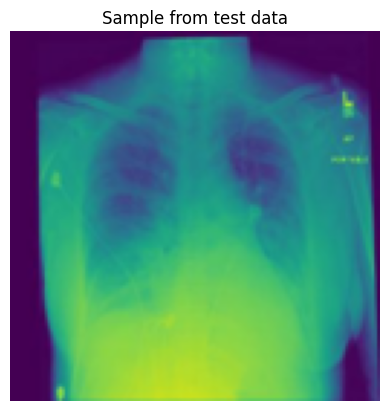

Predicted Class:Lung_Opacity
Ground Truth:Lung_Opacity


In [21]:
import random 
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image
model.eval()
idex = random.randrange(len(test_data.dataset))
img, label = test_data.dataset[idex]
unnorm= img = img * 0.5 + 0.5
plt.imshow(to_pil_image(unnorm))
plt.axis("off")
plt.title("Sample from test data")
plt.show()
with torch.no_grad():
    logits = model(img.unsqueeze(0).to(device))
    pred = logits.argmax(1).item()
class_names = test_data.dataset.classes
print(f"Predicted Class:{class_names[pred]}")
print(f"Ground Truth:{class_names[label]}")